In [ ]:
# Install library yang dibutuhkan
# (pandas & matplotlib sudah ada di Colab, tapi kita pastikan versinya)
!pip install pandas scikit-learn matplotlib -q
print('✅ Semua library siap!')

✅ Semua library siap!


In [ ]:
from google.colab import files
import io

print('📂 Silakan upload ketiga file CSV Anda...')
uploaded = files.upload()

# Konfirmasi file yang terupload
print()
print('File yang berhasil diupload:')
for fname in uploaded.keys():
    print(f'  ✅ {fname}')

# Cek kelengkapan file
required = ['training_bbri_colab.csv', 'test_bbri_colab.csv', 'forward_bbri_colab.csv']
missing  = [f for f in required if f not in uploaded]
if missing:
    print()
    print('⚠️  File berikut BELUM diupload:', missing)
    print('   Jalankan ulang cell ini dan upload file yang kurang!')
else:
    print()
    print('✅ Semua file lengkap! Lanjutkan ke cell berikutnya.')

📂 Silakan upload ketiga file CSV Anda...


Saving forward_bbri_colab.csv to forward_bbri_colab.csv
Saving test_bbri_colab.csv to test_bbri_colab.csv
Saving training_bbri_colab.csv to training_bbri_colab.csv

File yang berhasil diupload:
  ✅ forward_bbri_colab.csv
  ✅ test_bbri_colab.csv
  ✅ training_bbri_colab.csv

✅ Semua file lengkap! Lanjutkan ke cell berikutnya.


In [ ]:
import pandas as pd
from collections import Counter

# Load data dari file yang sudah diupload
train_df   = pd.read_csv(io.BytesIO(uploaded['training_bbri_colab.csv']))
test_df    = pd.read_csv(io.BytesIO(uploaded['test_bbri_colab.csv']))
forward_df = pd.read_csv(io.BytesIO(uploaded['forward_bbri_colab.csv']))

ATTRS = ['Arah_HariIni', 'Volume_Kategori', 'Rentang_Volatilitas', 'Gap_Pembukaan']
LABEL = 'Label_Keputusan'

print('=' * 55)
print('   EKSPLORASI DATA')
print('=' * 55)
print(f'Training  : {len(train_df)} baris  ({len(train_df)/(len(train_df)+len(test_df))*100:.0f}%)')
print(f'Test      : {len(test_df)} baris  ({len(test_df)/(len(train_df)+len(test_df))*100:.0f}%)')
print(f'Forward   : {len(forward_df)} baris  (prediksi ke depan)')
print()

print('Distribusi Label — Training:')
print(train_df[LABEL].value_counts().to_frame().rename(columns={LABEL: 'Jumlah'}))
print()

print('5 Baris Pertama Training:')
display(train_df[ATTRS + [LABEL]].head())
print()
print('Data Forward (prediksi berikutnya):')
display(forward_df)

   EKSPLORASI DATA
Training  : 296 baris  (80%)
Test      : 74 baris  (20%)
Forward   : 1 baris  (prediksi ke depan)

Distribusi Label — Training:
                 count
Label_Keputusan       
Tidak              166
Beli               130

5 Baris Pertama Training:


,Arah_HariIni,Volume_Kategori,Rentang_Volatilitas,Gap_Pembukaan,Label_Keputusan
0,Turun,Rendah,Lebar,Gap_Naik,Tidak
1,Turun,Rendah,Sempit,Gap_Naik,Tidak
2,Turun,Rendah,Sempit,Gap_Turun,Beli
3,Naik,Rendah,Sempit,Gap_Naik,Tidak
4,Turun,Rendah,Sempit,Gap_Turun,Tidak



Data Forward (prediksi berikutnya):


,Arah_HariIni,Volume_Kategori,Rentang_Volatilitas,Gap_Pembukaan
0,Naik,Sedang,Sempit,Gap_Naik


In [ ]:
def gini(counter):
    """Hitung Gini impurity dari distribusi kelas."""
    n = sum(counter.values())
    if n == 0:
        return 0.0
    return 1.0 - sum((c / n) ** 2 for c in counter.values())


def weighted_gini(subset, attr_idx):
    """
    Hitung Weighted Gini untuk satu atribut.
    Rumus: sum( |Sv|/|S| * Gini(Sv) ) untuk setiap nilai v atribut.
    """
    groups = {}
    for row in subset:
        groups.setdefault(row[attr_idx], []).append(row)
    n = len(subset)
    wg, detail = 0.0, {}
    for val, rows in groups.items():
        cnt = Counter(r[-1] for r in rows)
        g   = gini(cnt)
        wg += (len(rows) / n) * g
        detail[val] = {'distribusi': dict(cnt), 'gini': round(g, 4)}
    return round(wg, 4), detail


def best_split(subset, exclude=None):
    """Pilih atribut dengan Weighted Gini terkecil (terbaik)."""
    exclude = exclude or []
    parent_cnt = Counter(r[-1] for r in subset)
    print(f'  n={len(subset)} | distribusi={dict(parent_cnt)} | Gini_parent={round(gini(parent_cnt),4)}')
    results = {}
    for i, attr in enumerate(ATTRS):
        if attr in exclude:
            continue
        wg, detail = weighted_gini(subset, i)
        results[attr] = wg
        print(f'    [{attr}] weighted_Gini = {wg}')
        for val, info in detail.items():
            print(f'      nilai="{val}" → {info}')
    best_attr = min(results, key=results.get)
    print(f'  ✔ Split terpilih: {best_attr}  (weighted_Gini = {results[best_attr]})')
    print()
    return best_attr


print('✅ Fungsi Gini berhasil didefinisikan!')

# Demo: hitung Gini ROOT dari data training
train = list(train_df[ATTRS + [LABEL]].itertuples(index=False, name=None))
test  = list(test_df[ATTRS + [LABEL]].itertuples(index=False, name=None))
cnt_all = Counter(r[-1] for r in train)
print()
print(f'Gini seluruh data training = {round(gini(cnt_all), 4)}')
print(f'  (0 = murni satu kelas, 0.5 = paling kotor / seimbang 50:50)')

✅ Fungsi Gini berhasil didefinisikan!

Gini seluruh data training = 0.4926
  (0 = murni satu kelas, 0.5 = paling kotor / seimbang 50:50)


In [ ]:
print('=' * 60)
print('  INDUKSI DECISION TREE — GINI INDEX')
print('  Dataset: Saham BBRI | max_depth = 2 | Multi-way Split')
print('=' * 60)

# ── LEVEL 1: ROOT NODE ──
print()
print('┌─────────────────────────────────┐')
print('│         ROOT  (Level 1)         │')
print('└─────────────────────────────────┘')
root_attr = best_split(train)
root_idx  = ATTRS.index(root_attr)

# Kelompokkan data berdasarkan nilai ROOT
groups_l1 = {}
for row in train:
    groups_l1.setdefault(row[root_idx], []).append(row)

tree       = {}   # (val_l1, attr_l2, val_l2) → label
leaf_stats = []   # (error, total) untuk hitung training error

# ── LEVEL 2: CABANG ──
print('┌─────────────────────────────────┐')
print('│       CABANG  (Level 2)         │')
print('└─────────────────────────────────┘')

for val1, subset in sorted(groups_l1.items()):
    print(f'\n  ┌─ {root_attr} = "{val1}"  (n={len(subset)})')
    cnt = Counter(r[-1] for r in subset)

    # Jika data sudah murni / terlalu sedikit → langsung jadi leaf
    if len(cnt) == 1 or len(subset) < 2:
        label = cnt.most_common(1)[0][0]
        err   = len(subset) - cnt.most_common(1)[0][1]
        print(f'  └── LEAF → "{label}"  (murni)  error={err}/{len(subset)}')
        tree[(val1, None, None)] = label
        leaf_stats.append((err, len(subset)))
        continue

    # Cari atribut split Level 2 (exclude atribut ROOT)
    attr2 = best_split(subset, exclude=[root_attr])
    idx2  = ATTRS.index(attr2)

    # Bagi lagi berdasarkan atribut Level 2
    groups_l2 = {}
    for row in subset:
        groups_l2.setdefault(row[idx2], []).append(row)

    for val2, sub2 in sorted(groups_l2.items()):
        cnt2  = Counter(r[-1] for r in sub2)
        label = cnt2.most_common(1)[0][0]
        err   = len(sub2) - cnt2.most_common(1)[0][1]
        print(f'  │   {attr2}="{val2}" → LEAF="{label}"  dist={dict(cnt2)}  error={err}/{len(sub2)}')
        tree[(val1, attr2, val2)] = label
        leaf_stats.append((err, len(sub2)))

print()
print('✅ Pohon berhasil dibangun!')

  INDUKSI DECISION TREE — GINI INDEX
  Dataset: Saham BBRI | max_depth = 2 | Multi-way Split

┌─────────────────────────────────┐
│         ROOT  (Level 1)         │
└─────────────────────────────────┘
  n=296 | distribusi={'Tidak': 166, 'Beli': 130} | Gini_parent=0.4926
    [Arah_HariIni] weighted_Gini = 0.4926
      nilai="Turun" → {'distribusi': {'Tidak': 93, 'Beli': 74}, 'gini': 0.4935}
      nilai="Naik" → {'distribusi': {'Tidak': 73, 'Beli': 56}, 'gini': 0.4913}
    [Volume_Kategori] weighted_Gini = 0.4919
      nilai="Rendah" → {'distribusi': {'Tidak': 63, 'Beli': 45}, 'gini': 0.4861}
      nilai="Tinggi" → {'distribusi': {'Tidak': 54, 'Beli': 43}, 'gini': 0.4936}
      nilai="Sedang" → {'distribusi': {'Beli': 42, 'Tidak': 49}, 'gini': 0.497}
    [Rentang_Volatilitas] weighted_Gini = 0.4832
      nilai="Lebar" → {'distribusi': {'Tidak': 83, 'Beli': 83}, 'gini': 0.5}
      nilai="Sempit" → {'distribusi': {'Tidak': 83, 'Beli': 47}, 'gini': 0.4617}
    [Gap_Pembukaan] weighted_Gini

In [ ]:
total_err = sum(e for e, _ in leaf_stats)
total_n   = sum(n for _, n in leaf_stats)
n_leaf    = len(leaf_stats)
OMEGA     = 0.5   # penalti per daun (pessimistic pruning)

optimistic  = total_err / total_n
pessimistic = (total_err + OMEGA * n_leaf) / total_n

print('=' * 55)
print('  TRAINING ERROR')
print('=' * 55)
print(f'  Jumlah daun (leaf)       : {n_leaf}')
print(f'  Jumlah data training     : {total_n}')
print(f'  Total prediksi salah     : {total_err}')
print()
print(f'  Training Error           : {total_err}/{total_n} = {optimistic*100:.2f}%')
print()
print(f'  Optimistic Estimate      : {optimistic*100:.2f}%')
print(f'    → sama dengan training error (tanpa penalti)')
print()
print(f'  Pessimistic Estimate     : ({total_err} + {OMEGA}×{n_leaf}) / {total_n} = {pessimistic*100:.2f}%')
print(f'    → training error + penalti Ω={OMEGA} per daun')
print()
print('  MDL: sesuaikan dengan skema encoding dari dosen.')

  TRAINING ERROR
  Jumlah daun (leaf)       : 6
  Jumlah data training     : 296
  Total prediksi salah     : 126

  Training Error           : 126/296 = 42.57%

  Optimistic Estimate      : 42.57%
    → sama dengan training error (tanpa penalti)

  Pessimistic Estimate     : (126 + 0.5×6) / 296 = 43.58%
    → training error + penalti Ω=0.5 per daun

  MDL: sesuaikan dengan skema encoding dari dosen.


In [ ]:
# Kelas mayoritas sebagai fallback jika kombinasi fitur belum pernah dilihat
majority_class = Counter(r[-1] for r in train).most_common(1)[0][0]

def predict(row):
    """Telusuri pohon dari ROOT ke LEAF untuk satu baris data."""
    v1 = row[root_idx]
    for (val1, attr2, val2), label in tree.items():
        if val1 != v1:
            continue
        if attr2 is None:           # langsung leaf di level 1
            return label
        idx2 = ATTRS.index(attr2)
        if row[idx2] == val2:
            return label
    return majority_class           # fallback: kelas mayoritas


# ── Evaluasi pada Test Set ──
print('=' * 55)
print(f'  EVALUASI TEST SET  ({len(test)} baris)')
print('=' * 55)
print()

results = []
test_errors = 0
for i, row in enumerate(test):
    pred   = predict(row)
    actual = row[-1]
    ok     = pred == actual
    if not ok:
        test_errors += 1
    results.append({'No': i+1, 'Aktual': actual, 'Prediksi': pred,
                    'Status': '✔' if ok else '✘ SALAH'})

# Tampilkan tabel hasil per baris
df_results = pd.DataFrame(results)
display(df_results.style.applymap(
    lambda v: 'color:green' if v == '✔' else ('color:red' if '✘' in str(v) else ''),
    subset=['Status']
))

test_acc  = (len(test) - test_errors) / len(test)
test_err  = test_errors / len(test)
print()
print(f'  Test Error    : {test_errors}/{len(test)} = {test_err*100:.2f}%')
print(f'  Test Accuracy : {test_acc*100:.2f}%')

  EVALUASI TEST SET  (74 baris)



/tmp/ipykernel_1664/395343412.py:37: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(df_results.style.applymap(


,No,Aktual,Prediksi,Status
0,1,Tidak,Tidak,✔
1,2,Beli,Tidak,✘ SALAH
2,3,Tidak,Tidak,✔
3,4,Beli,Tidak,✘ SALAH
4,5,Beli,Tidak,✘ SALAH
5,6,Beli,Tidak,✘ SALAH
6,7,Tidak,Tidak,✔
7,8,Tidak,Tidak,✔
8,9,Tidak,Tidak,✔
9,10,Tidak,Tidak,✔



  Test Error    : 34/74 = 45.95%
  Test Accuracy : 54.05%


In [ ]:
print('=' * 55)
print('  RINGKASAN HASIL DECISION TREE')
print('=' * 55)
print(f'  Atribut ROOT (Level 1)    : {root_attr}')
print(f'  Total data training       : {total_n} baris')
print(f'  Total data test           : {len(test)} baris')
print(f'  Jumlah leaf               : {n_leaf}')
print()
print(f'  Training Error            : {optimistic*100:.2f}%')
print(f'  Optimistic Estimate       : {optimistic*100:.2f}%')
print(f'  Pessimistic Estimate      : {pessimistic*100:.2f}%')
print(f'  Test Error Aktual         : {test_err*100:.2f}%')
print(f'  Test Accuracy Aktual      : {test_acc*100:.2f}%')

  RINGKASAN HASIL DECISION TREE
  Atribut ROOT (Level 1)    : Rentang_Volatilitas
  Total data training       : 296 baris
  Total data test           : 74 baris
  Jumlah leaf               : 6

  Training Error            : 42.57%
  Optimistic Estimate       : 42.57%
  Pessimistic Estimate      : 43.58%
  Test Error Aktual         : 45.95%
  Test Accuracy Aktual      : 54.05%


In [ ]:
fwd_row  = list(forward_df[ATTRS].itertuples(index=False, name=None))[0]
pred_fwd = predict(fwd_row)

print('=' * 55)
print('  PREDIKSI SESI BERIKUTNYA')
print('=' * 55)
print()
for attr, val in zip(ATTRS, fwd_row):
    print(f'  {attr:<30}: {val}')
print()
print(f'  ► Prediksi Keputusan : {pred_fwd}')
print()
print('  ⚠  PERINGATAN: Hasil ini adalah output model EDUKATIF.')
print('     Bukan rekomendasi investasi!')

  PREDIKSI SESI BERIKUTNYA

  Arah_HariIni                  : Naik
  Volume_Kategori               : Sedang
  Rentang_Volatilitas           : Sempit
  Gap_Pembukaan                 : Gap_Naik

  ► Prediksi Keputusan : Tidak

  ⚠  PERINGATAN: Hasil ini adalah output model EDUKATIF.
     Bukan rekomendasi investasi!


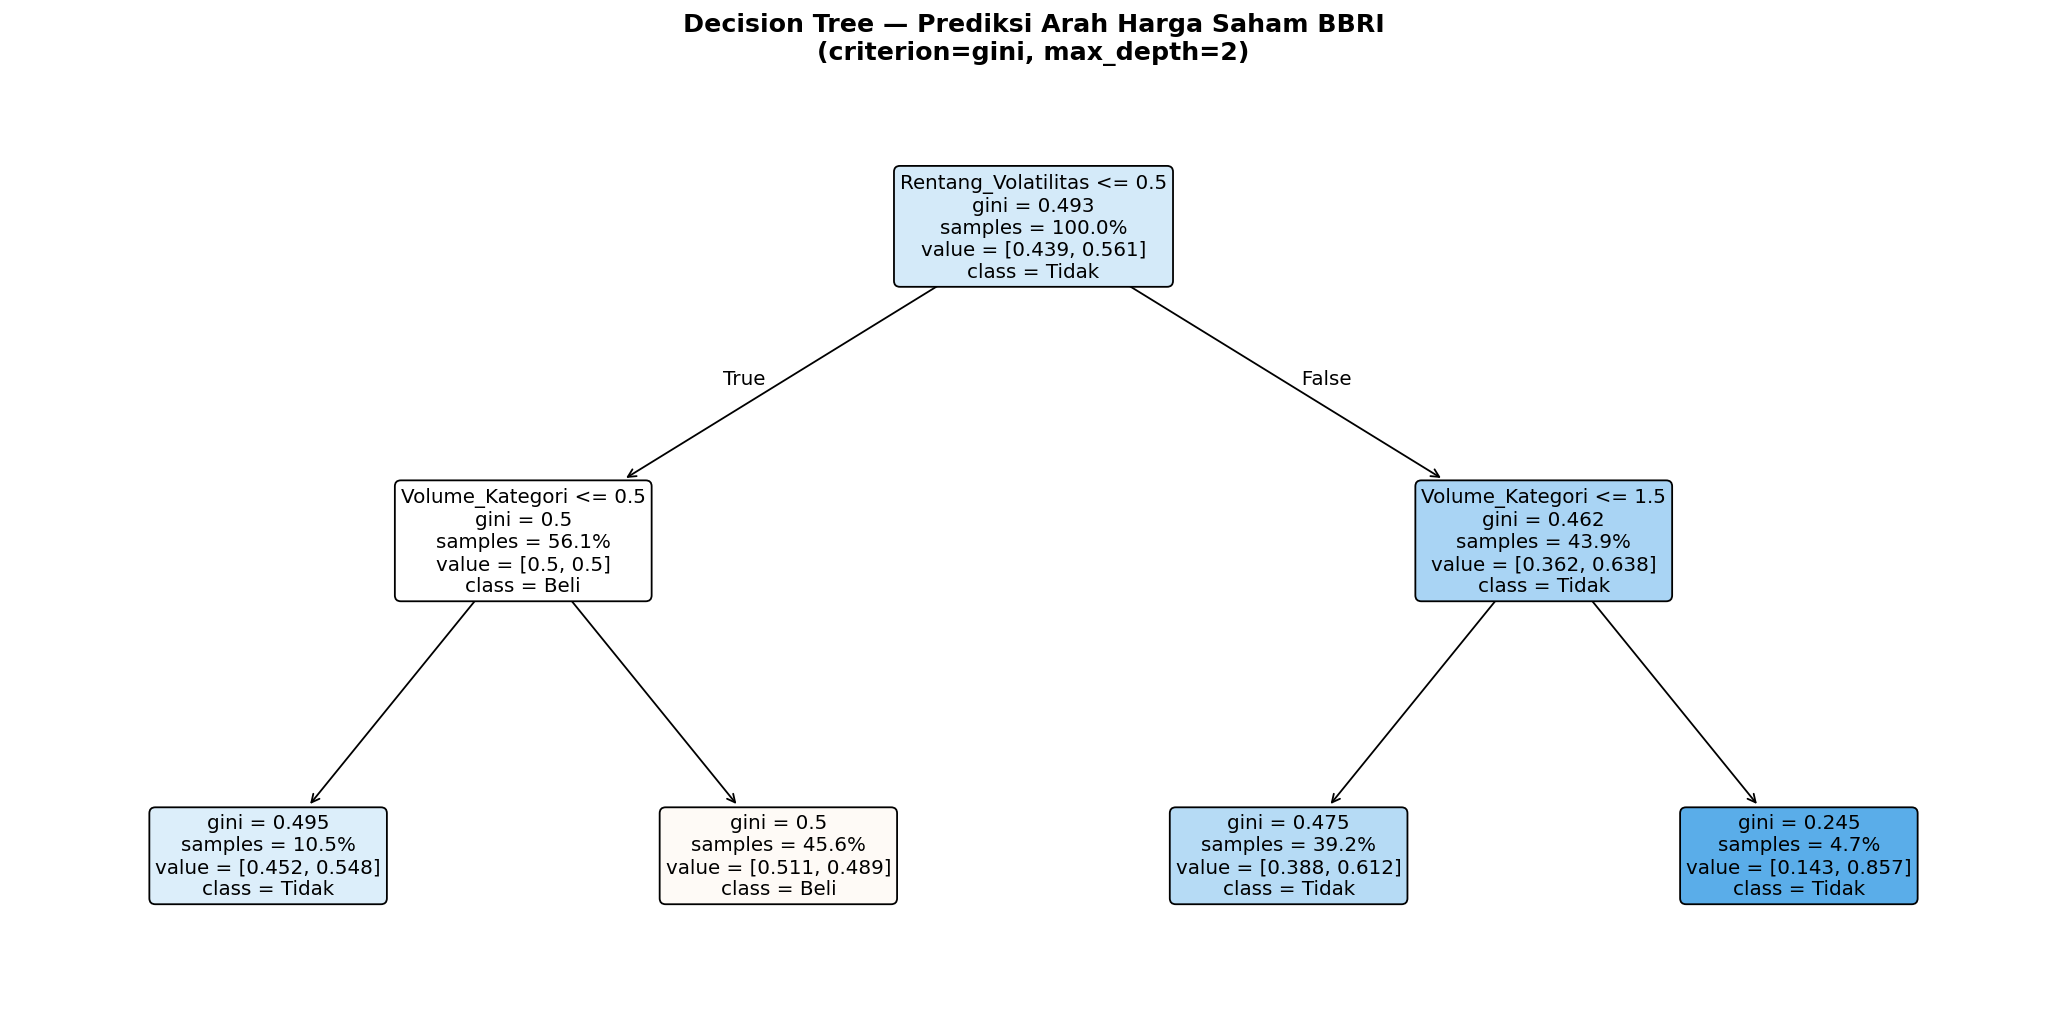

✅ Gambar pohon berhasil ditampilkan & disimpan sebagai decision_tree_bbri.png


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Encode atribut kategorikal ke angka (sklearn perlu numerik)
encoders = {}
X_train  = pd.DataFrame()
X_test   = pd.DataFrame()
X_fwd_sk = pd.DataFrame()

for col in ATTRS:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[col], test_df[col], forward_df[col]]))
    encoders[col]  = le
    X_train[col]   = le.transform(train_df[col])
    X_test[col]    = le.transform(test_df[col])
    X_fwd_sk[col]  = le.transform(forward_df[col])

y_train_sk = train_df[LABEL]

# Training dengan sklearn
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42)
dt_model.fit(X_train, y_train_sk)

# Visualisasi pohon
fig, ax = plt.subplots(figsize=(16, 8), dpi=130)
plot_tree(
    dt_model,
    feature_names=ATTRS,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    proportion=True,
    impurity=True,
    ax=ax
)
plt.title('Decision Tree — Prediksi Arah Harga Saham BBRI\n(criterion=gini, max_depth=2)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_bbri.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar pohon berhasil ditampilkan & disimpan sebagai decision_tree_bbri.png')

In [ ]:
# Download gambar pohon ke komputer lokal
from google.colab import files
files.download('decision_tree_bbri.png')
print('✅ File decision_tree_bbri.png diunduh ke komputer Anda.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File decision_tree_bbri.png diunduh ke komputer Anda.
